# Capstone Project: Phishing Website Detection Using Machine Learning

**Project topic:** cybersecurity / phishing detection  
**Dataset:** UCI Machine Learning Repository - Phishing Websites Dataset  
**Task:** binary classification: phishing website vs. legitimate website

This notebook follows a CRISP-DM style workflow: business understanding, data understanding, data preparation, modeling, evaluation, and interpretation.

## 1. Business Understanding

Phishing websites imitate trusted websites to trick users into revealing credentials, financial information, or other sensitive data. Security teams may need to triage large numbers of URLs or website indicators, and machine learning can help prioritize likely phishing sites for analyst review.

**Problem statement:** Can a supervised machine learning model classify websites as phishing or legitimate based on structured website features?

**Project goals:**

- Load and explore a cybersecurity-related dataset.
- Train at least two machine learning models.
- Evaluate model performance using accuracy, precision, recall, F1 score, confusion matrix, ROC curve, and AUC-ROC.
- Interpret false positives and false negatives in a cybersecurity context.
- Discuss limitations and responsible AI considerations.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import io
import re
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from IPython.display import display, Markdown

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (8, 5)

## 3. Load Dataset

The code below first looks for a local copy of the UCI Phishing Websites dataset. If the file is not present, it attempts to download the dataset from the UCI Machine Learning Repository.

For GitHub use, place either `Training Dataset.arff` or a compatible phishing CSV file in the project `data/` folder.

In [2]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

DIRECT_ARFF_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00327/Training%20Dataset.arff'
ZIP_URL = 'https://archive.ics.uci.edu/static/public/327/phishing%2Bwebsites.zip'


def parse_arff_to_dataframe(arff_text):
    """Parse a simple ARFF file into a pandas DataFrame."""
    attributes = []
    rows = []
    in_data = False
    attribute_pattern = re.compile(r"^@attribute\s+(['\"]?)(.+?)\1\s+", re.IGNORECASE)

    for raw_line in arff_text.splitlines():
        line = raw_line.strip()
        if not line or line.startswith('%'):
            continue

        lower = line.lower()
        if lower.startswith('@attribute'):
            match = attribute_pattern.match(line)
            if match:
                attributes.append(match.group(2).strip().replace(' ', '_'))
            continue

        if lower.startswith('@data'):
            in_data = True
            continue

        if in_data:
            rows.append([value.strip() for value in line.split(',')])

    parsed = pd.DataFrame(rows, columns=attributes)
    for col in parsed.columns:
        parsed[col] = pd.to_numeric(parsed[col], errors='coerce')
    return parsed


def load_phishing_dataset():
    """Load local dataset if available; otherwise download from UCI."""
    local_arff_candidates = [
        DATA_DIR / 'Training Dataset.arff',
        DATA_DIR / 'Training_Dataset.arff',
        Path('Training Dataset.arff'),
        Path('Training_Dataset.arff')
    ]
    local_csv_candidates = [
        DATA_DIR / 'phishing_websites.csv',
        DATA_DIR / 'phishing.csv',
        Path('phishing_websites.csv'),
        Path('phishing.csv')
    ]

    for path in local_csv_candidates:
        if path.exists():
            print(f'Loaded local CSV dataset: {path}')
            return pd.read_csv(path)

    for path in local_arff_candidates:
        if path.exists():
            print(f'Loaded local ARFF dataset: {path}')
            return parse_arff_to_dataframe(path.read_text(encoding='utf-8', errors='ignore'))

    print('No local dataset found. Attempting to download the ARFF file from UCI...')
    try:
        with urllib.request.urlopen(DIRECT_ARFF_URL, timeout=30) as response:
            text = response.read().decode('utf-8', errors='ignore')
        out_path = DATA_DIR / 'Training Dataset.arff'
        out_path.write_text(text, encoding='utf-8')
        print(f'Downloaded and saved dataset to: {out_path}')
        return parse_arff_to_dataframe(text)
    except Exception as direct_error:
        print('Direct ARFF download failed:', direct_error)
        print('Attempting to download the ZIP file from UCI...')

    try:
        with urllib.request.urlopen(ZIP_URL, timeout=30) as response:
            zip_bytes = response.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            arff_name = [name for name in zf.namelist() if name.lower().endswith('.arff') and 'training' in name.lower()][0]
            text = zf.read(arff_name).decode('utf-8', errors='ignore')
        out_path = DATA_DIR / 'Training Dataset.arff'
        out_path.write_text(text, encoding='utf-8')
        print(f'Downloaded ZIP and extracted dataset to: {out_path}')
        return parse_arff_to_dataframe(text)
    except Exception as zip_error:
        raise RuntimeError('Could not load the dataset. Download Training Dataset.arff from UCI and place it in the data/ folder.') from zip_error


df = load_phishing_dataset()
print('Dataset loaded successfully.')
display(df.head())

Loaded local ARFF dataset: data\Training Dataset.arff
Dataset loaded successfully.


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Data Understanding

This section reviews the dataset shape, variables, missing values, and class distribution.

In [3]:
print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nDataset info:')
display(df.info())

print('\nSummary statistics:')
display(df.describe().T)

Dataset shape: (11055, 31)

Columns:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null 

None


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print('No missing values were found in the dataset.')
else:
    print('Missing values by column:')
    display(missing_values)

No missing values were found in the dataset.


In [5]:
possible_targets = ['Result', 'result', 'Class', 'class', 'Label', 'label']
target_col = None
for candidate in possible_targets:
    if candidate in df.columns:
        target_col = candidate
        break

if target_col is None:
    raise ValueError('Target column not found. Expected one of: Result, Class, Label.')

print('Target column:', target_col)
print('\nOriginal target value counts:')
display(df[target_col].value_counts().sort_index())

Target column: Result

Original target value counts:


Result
-1    4898
 1    6157
Name: count, dtype: int64

Mapped target distribution:


Result
Legitimate    6157
Phishing      4898
Name: count, dtype: int64

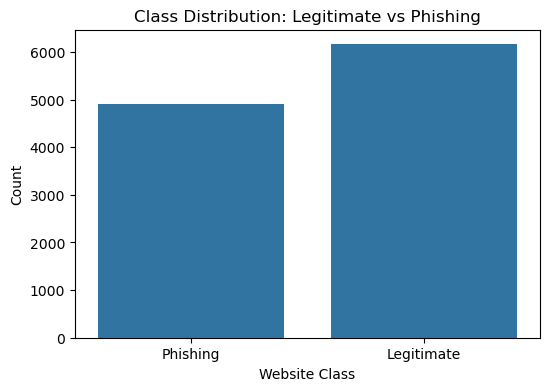

In [6]:
# UCI Phishing Websites uses Result = -1 for phishing and Result = 1 for legitimate.
# This project maps phishing to 1 and legitimate to 0 so the positive class is the security event of interest.
if set(df[target_col].dropna().unique()).issubset({-1, 1}):
    y = (df[target_col] == -1).astype(int)
else:
    y = df[target_col].astype(int)

X = df.drop(columns=[target_col])

class_distribution = y.value_counts().rename(index={0: 'Legitimate', 1: 'Phishing'})
print('Mapped target distribution:')
display(class_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: 'Legitimate', 1: 'Phishing'}))
plt.title('Class Distribution: Legitimate vs Phishing')
plt.xlabel('Website Class')
plt.ylabel('Count')
plt.show()

Top 10 features by absolute correlation with phishing label:


,correlation_with_phishing
SSLfinal_State,-0.714741
URL_of_Anchor,-0.692935
Prefix_Suffix,-0.348606
web_traffic,-0.346103
having_Sub_Domain,-0.298323
Request_URL,-0.253372
Links_in_tags,-0.248229
Domain_registeration_length,0.225789
SFH,-0.221419
Google_Index,-0.128950


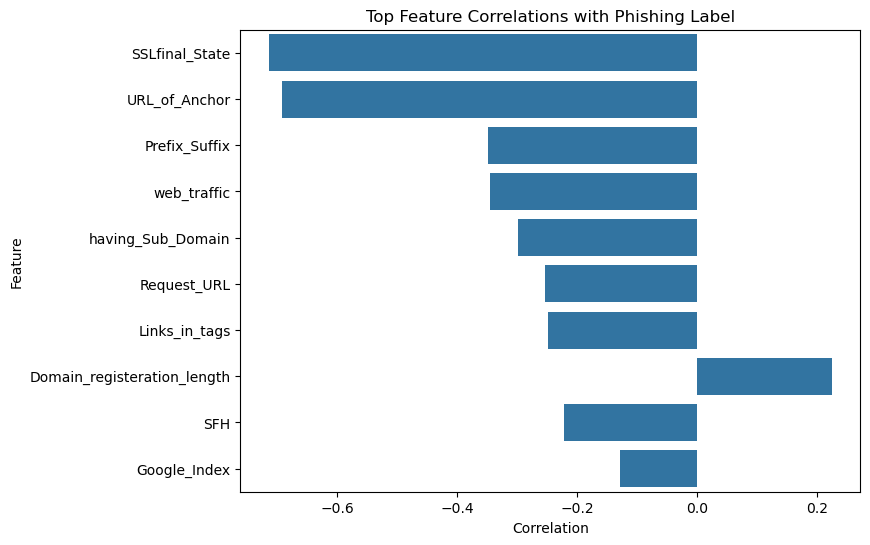

In [7]:
analysis_df = X.copy()
analysis_df['is_phishing'] = y

correlations = analysis_df.corr(numeric_only=True)['is_phishing'].drop('is_phishing')
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

top_correlations = correlations.head(10)
print('Top 10 features by absolute correlation with phishing label:')
display(top_correlations.to_frame('correlation_with_phishing'))

plt.figure(figsize=(8, 6))
sns.barplot(x=top_correlations.values, y=top_correlations.index)
plt.title('Top Feature Correlations with Phishing Label')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

## 5. Data Preparation

The target is mapped so that `0 = legitimate website` and `1 = phishing website`. A stratified train/test split preserves the class balance in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('\nTraining target distribution:')
display(y_train.value_counts(normalize=True).rename(index={0: 'Legitimate', 1: 'Phishing'}))
print('\nTest target distribution:')
display(y_test.value_counts(normalize=True).rename(index={0: 'Legitimate', 1: 'Phishing'}))

Training set shape: (8844, 30)
Test set shape: (2211, 30)

Training target distribution:


Result
Legitimate    0.556988
Phishing      0.443012
Name: proportion, dtype: float64


Test target distribution:


Result
Legitimate    0.556762
Phishing      0.443238
Name: proportion, dtype: float64

## 6. Model Training

Two models are trained:

1. **Logistic Regression** - a baseline model that is easier to interpret.
2. **Random Forest** - an ensemble model that can capture nonlinear relationships and provide feature importance values.

In [9]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)

print('Training complete.')

Training Logistic Regression...
Training Random Forest...
Training complete.


## 7. Model Evaluation

The capstone evaluates each model using accuracy, precision, recall, F1 score, confusion matrix, ROC curve, and AUC-ROC. For phishing detection, **recall** matters because a false negative means a phishing website was incorrectly classified as legitimate.

In [10]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_score)
    }

    print(f'\n{name} Classification Report')
    print('-' * 60)
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing'], zero_division=0))

    return metrics, y_pred, y_score

results = []
predictions = {}
scores = {}

for name, model in models.items():
    metrics, y_pred, y_score = evaluate_model(name, model, X_test, y_test)
    results.append(metrics)
    predictions[name] = y_pred
    scores[name] = y_score

metrics_df = pd.DataFrame(results).set_index('Model')
print('\nModel comparison:')
display(metrics_df.style.format('{:.4f}'))


Logistic Regression Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.93      0.94      0.94      1231
    Phishing       0.93      0.92      0.92       980

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211


Random Forest Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97      1231
    Phishing       0.97      0.97      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Model comparison:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9317,0.9295,0.9153,0.9224,0.9786
Random Forest,0.9706,0.9664,0.9673,0.9669,0.9964


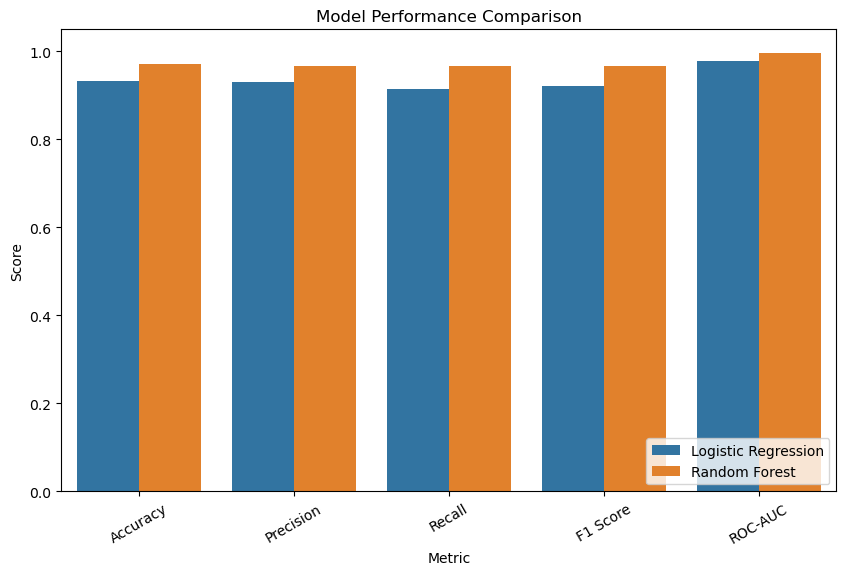

In [11]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = metrics_df[metrics_to_plot].reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

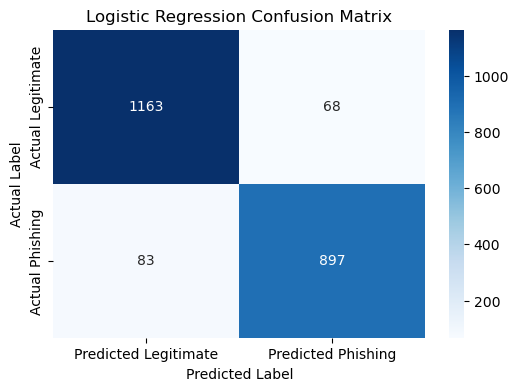

Logistic Regression: TN=1163, FP=68, FN=83, TP=897


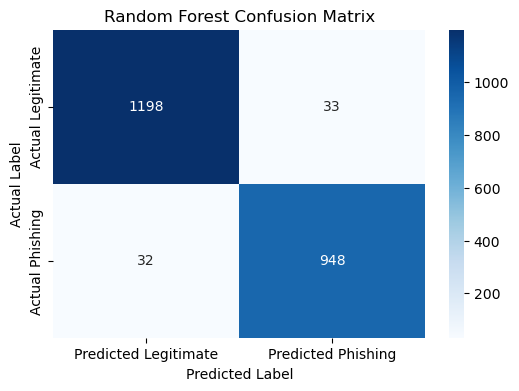

Random Forest: TN=1198, FP=33, FN=32, TP=948


In [12]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted Legitimate', 'Predicted Phishing'],
        yticklabels=['Actual Legitimate', 'Actual Phishing']
    )
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

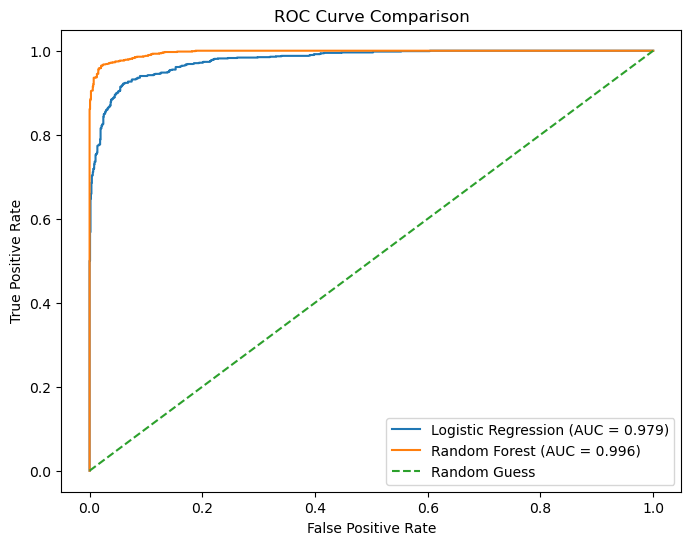

In [13]:
plt.figure(figsize=(8, 6))

for name, y_score in scores.items():
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 8. Feature Importance

Feature importance helps explain which website characteristics contributed most strongly to model predictions.

Top 10 Random Forest feature importances:


,importance
SSLfinal_State,0.339041
URL_of_Anchor,0.263593
web_traffic,0.072315
having_Sub_Domain,0.060615
Prefix_Suffix,0.048790
Links_in_tags,0.042411
SFH,0.021176
Request_URL,0.016954
Domain_registeration_length,0.014705
Links_pointing_to_page,0.014635


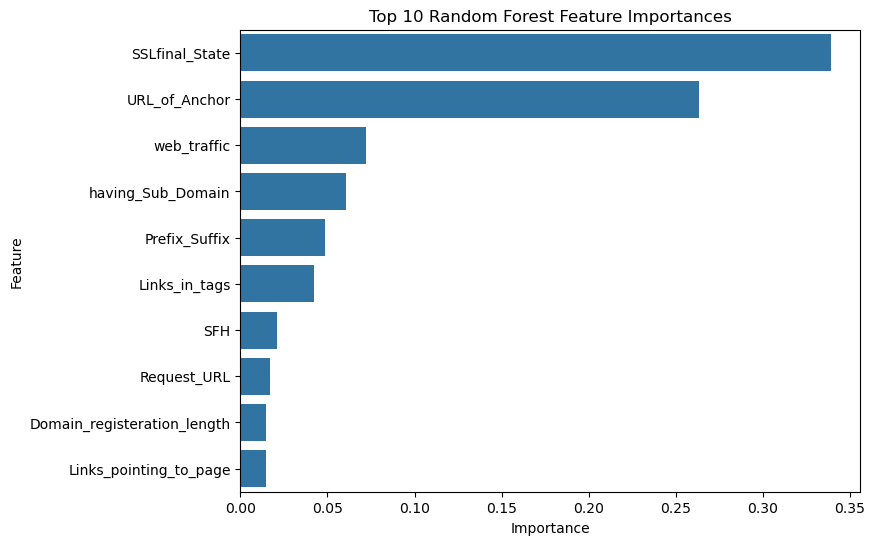

In [14]:
rf_model = models['Random Forest']
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

top_features = feature_importance.head(10)
print('Top 10 Random Forest feature importances:')
display(top_features.to_frame('importance'))

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Top 10 Logistic Regression coefficients by absolute value:


,coefficient
URL_of_Anchor,-2.260538
Prefix_Suffix,-2.162262
SSLfinal_State,-1.482308
SFH,-0.715456
Links_in_tags,-0.620655
having_IP_Address,-0.617318
web_traffic,-0.599914
having_Sub_Domain,-0.508487
Shortining_Service,0.497527
Links_pointing_to_page,-0.475354


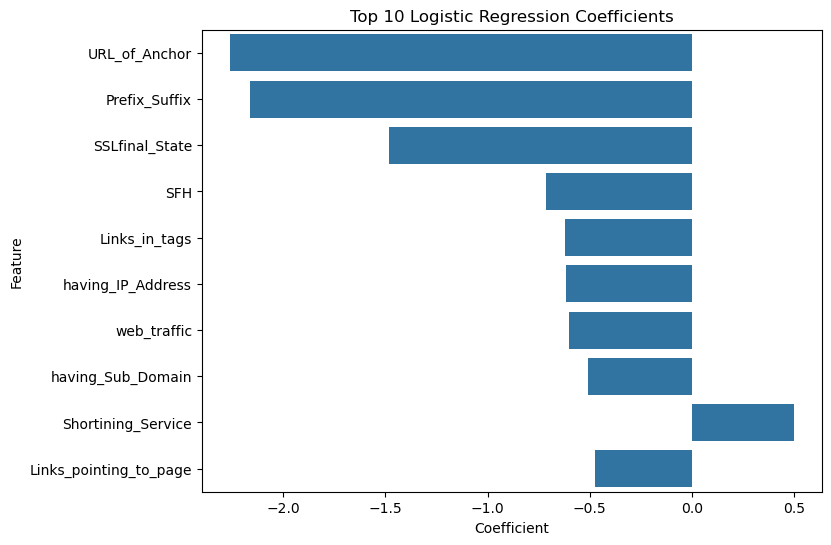

In [15]:
logistic_model = models['Logistic Regression'].named_steps['model']
logistic_coefficients = pd.Series(logistic_model.coef_[0], index=X.columns)
logistic_coefficients = logistic_coefficients.reindex(logistic_coefficients.abs().sort_values(ascending=False).index)

print('Top 10 Logistic Regression coefficients by absolute value:')
display(logistic_coefficients.head(10).to_frame('coefficient'))

plt.figure(figsize=(8, 6))
sns.barplot(x=logistic_coefficients.head(10).values, y=logistic_coefficients.head(10).index)
plt.title('Top 10 Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

## 9. Interpretation and Reflection

Run the cell below after all model cells have executed. It generates a project summary using the actual metrics from this notebook run.

In [16]:
best_model_name = metrics_df.sort_values(['F1 Score', 'Recall', 'ROC-AUC'], ascending=False).index[0]
best_metrics = metrics_df.loc[best_model_name]
best_cm = confusion_matrix(y_test, predictions[best_model_name])
tn, fp, fn, tp = best_cm.ravel()
important_features = ', '.join(top_features.index[:5])

summary_md = f"""
## Final Project Interpretation and Reflection

### Model Performance

The best-performing model in this run was **{best_model_name}**. It achieved an accuracy of **{best_metrics['Accuracy']:.2%}**, precision of **{best_metrics['Precision']:.2%}**, recall of **{best_metrics['Recall']:.2%}**, F1 score of **{best_metrics['F1 Score']:.2%}**, and ROC-AUC of **{best_metrics['ROC-AUC']:.4f}**.

Accuracy was useful as a general performance measure, but it was not enough by itself. In phishing detection, the more important issue is whether the model can identify phishing websites without producing too many missed detections or false alarms.

### Confusion Matrix Interpretation

For the best model, the confusion matrix showed:

- **True negatives:** {tn} legitimate websites correctly classified as legitimate.
- **False positives:** {fp} legitimate websites incorrectly flagged as phishing.
- **False negatives:** {fn} phishing websites incorrectly classified as legitimate.
- **True positives:** {tp} phishing websites correctly classified as phishing.

The most concerning errors are the false negatives because they represent phishing websites that would not be flagged by the model. In a real cybersecurity environment, those missed detections could expose users to credential theft, malware, or fraud.

### Key Predictive Features

The Random Forest model identified the following features as especially important: **{important_features}**. These features appear to be useful indicators for distinguishing suspicious websites from legitimate ones.

### Cybersecurity Relevance

This project shows how machine learning can support phishing detection by analyzing structured website features and producing a classification that helps analysts prioritize suspicious sites. The model could be used as part of a security workflow to triage URLs, support alert enrichment, or assist user-protection systems.

### Limitations

The model has several limitations. It was trained on historical feature data, so it may not generalize perfectly to new phishing techniques. Some features may be dataset-specific and may not transfer cleanly to other environments. The model can also produce both false positives and false negatives, so it should not be used as the only decision-maker.

### Responsible AI Considerations

A phishing detection model should be used with human oversight, monitoring, and regular retraining. False positives can block or burden legitimate websites, while false negatives can create security exposure. A responsible deployment would include analyst review, performance monitoring, explainability, and clear escalation procedures.

### Future Improvements

Future work could test additional models, perform cross-validation, tune model hyperparameters, compare results on a newer phishing URL dataset, and add explainability tools such as SHAP or LIME to better understand prediction behavior.
"""

display(Markdown(summary_md))


## Final Project Interpretation and Reflection

### Model Performance

The best-performing model in this run was **Random Forest**. It achieved an accuracy of **97.06%**, precision of **96.64%**, recall of **96.73%**, F1 score of **96.69%**, and ROC-AUC of **0.9964**.

Accuracy was useful as a general performance measure, but it was not enough by itself. In phishing detection, the more important issue is whether the model can identify phishing websites without producing too many missed detections or false alarms.

### Confusion Matrix Interpretation

For the best model, the confusion matrix showed:

- **True negatives:** 1198 legitimate websites correctly classified as legitimate.
- **False positives:** 33 legitimate websites incorrectly flagged as phishing.
- **False negatives:** 32 phishing websites incorrectly classified as legitimate.
- **True positives:** 948 phishing websites correctly classified as phishing.

The most concerning errors are the false negatives because they represent phishing websites that would not be flagged by the model. In a real cybersecurity environment, those missed detections could expose users to credential theft, malware, or fraud.

### Key Predictive Features

The Random Forest model identified the following features as especially important: **SSLfinal_State, URL_of_Anchor, web_traffic, having_Sub_Domain, Prefix_Suffix**. These features appear to be useful indicators for distinguishing suspicious websites from legitimate ones.

### Cybersecurity Relevance

This project shows how machine learning can support phishing detection by analyzing structured website features and producing a classification that helps analysts prioritize suspicious sites. The model could be used as part of a security workflow to triage URLs, support alert enrichment, or assist user-protection systems.

### Limitations

The model has several limitations. It was trained on historical feature data, so it may not generalize perfectly to new phishing techniques. Some features may be dataset-specific and may not transfer cleanly to other environments. The model can also produce both false positives and false negatives, so it should not be used as the only decision-maker.

### Responsible AI Considerations

A phishing detection model should be used with human oversight, monitoring, and regular retraining. False positives can block or burden legitimate websites, while false negatives can create security exposure. A responsible deployment would include analyst review, performance monitoring, explainability, and clear escalation procedures.

### Future Improvements

Future work could test additional models, perform cross-validation, tune model hyperparameters, compare results on a newer phishing URL dataset, and add explainability tools such as SHAP or LIME to better understand prediction behavior.


## 10. Conclusion

This capstone demonstrated a complete machine learning workflow for phishing website detection. The analysis included dataset loading, exploratory data analysis, target preparation, model training, performance evaluation, confusion matrices, ROC curves, feature importance, and cybersecurity interpretation.

The project supports the conclusion that machine learning can help cybersecurity analysts identify suspicious websites, but the model should be treated as decision support rather than a fully autonomous security control.